# Beam search
Exact and fuzzy beam search for approximating WFSA intersection.

## TO-DO
- Get weights from Pynini graph search
- Debug why results are so different (use small lexicons)

In [100]:
import pynini
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass

## Data preparation utilities

In [101]:
ascii_table = pynini.SymbolTable()
ascii_table.add_symbol("<eps>")

symbol_range = (1, 256)

for i in range(*symbol_range):
    ascii_table.add_symbol(chr(i))

In [102]:
lexicon = [
    "foo",
    "fee",
    "ffoo",
    "bar",
    "boar",
    "fbar",
]

In [103]:


def generate_random_word():
    alpha_start = ord('a')
    alpha_end = ord('z')

    min_word_len = 3
    max_word_len = 10

    word_len = np.random.randint(low=min_word_len, high=max_word_len, size=(1,)).item()
    random_ints = np.random.randint(low=alpha_start, high=alpha_end, size=(word_len,))
    random_word = ''.join(chr(i) for i in random_ints)
    return random_word

random_wordlist = [generate_random_word() for _ in range(10)]

random_wordlist[:10]

['klgo',
 'pqlks',
 'rhllbhmjq',
 'recbhxpx',
 'mtbxuqk',
 'jcprp',
 'bjuefwork',
 'mll',
 'uxbutwys',
 'gkaomlk']

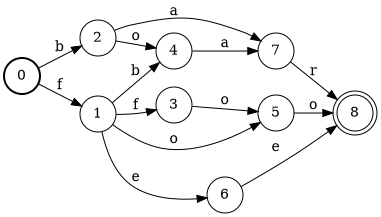

In [104]:
L = pynini.union(*lexicon)
L.set_input_symbols(ascii_table)
L.optimize()
L

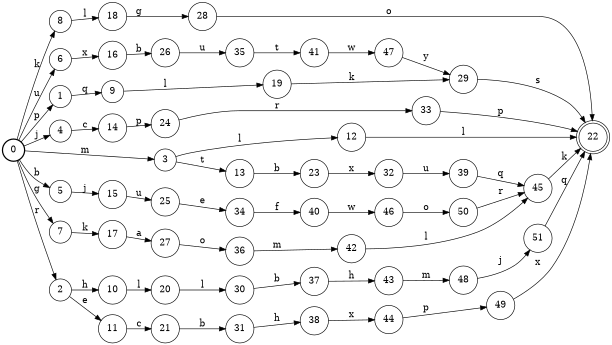

In [105]:
Lrand = pynini.union(*random_wordlist)
Lrand.set_input_symbols(ascii_table)
Lrand.optimize()
Lrand

In [106]:
def get_random_lexicon(num_words: int) -> pynini.Fst:
    wordlist = [generate_random_word() for _ in range(num_words)]
    lexicon = pynini.union(*wordlist)
    lexicon.optimize()
    return lexicon

## FST $\mapsto$ Compressed Sparse Row
Used by beam search functions

In [107]:
class WfsaCsr(NamedTuple):
    """
    Compressed Sparse Row representation of a WFSA with m states and n arcs.
    - `offsets`: n+1 array mapping state index to the first arc index
    - `final`: n array indicating final states
    - `next_states`: m array mapping arc index to target state index
    - `weights`: m array containing arc weights
    - `labels`: m array containing input labels for arcs
    """

    offsets: np.ndarray
    next_states: np.ndarray
    weights: np.ndarray
    final: np.ndarray
    labels: np.ndarray

    @classmethod
    def from_pynini(cls, wfsa: pynini.Fst) -> "WfsaCsr":
        """
        Compute a Compressed Sparse Row representation for the given FST.

        Arguments:
        - `fst`: the input FST to convert
        Returns:
        A `CSR` named tuple containing the CSR representation of the FST.
        """

        # beam search will expect an epsilon-free deterministic arc-sorted WFSA
        wfsa = pynini.determinize(wfsa)
        wfsa = pynini.rmepsilon(wfsa)
        wfsa = pynini.arcsort(wfsa)

        n = wfsa.num_states()

        # store final states
        final = np.zeros(n, dtype=bool)
        zero_weight = pynini.Weight.zero(wfsa.weight_type())

        # first compute offsets by counting the number of arcs leaving each state
        # check for final weights in same loop
        offsets = np.zeros(n + 1, dtype=np.int32)
        for s in wfsa.states():
            if wfsa.final(s) != zero_weight:
                final[s] = True
            offsets[s + 1] = wfsa.num_arcs(s)

        # then compute the prefix sum to get the starting index of arcs for each state
        np.cumsum(offsets, out=offsets)

        # the total number of arcs is the last value in offsets
        # (equivalent to the 'starting arc' of the final state, which has no outgoing arcs)
        total = int(offsets[-1])

        # arc arrays
        next_states = np.empty(total, dtype=np.int32)
        weights = np.empty(total, dtype=np.float32)
        labels = np.empty(total, dtype=np.int32)

        # populate the arc arrays by iterating over states and arcs
        for s in wfsa.states():
            i = offsets[s]
            for arc in wfsa.arcs(s):
                next_states[i] = arc.nextstate
                weights[i] = float(arc.weight)  # tropical -> float
                labels[i] = arc.ilabel
                i += 1

        return cls(
            offsets=offsets,
            final=final,
            next_states=next_states,
            weights=weights,
            labels=labels,
        )

In [108]:
@dataclass
class WfsaCsrBeam:
    """
    Dataclass representing a single beam search hypothesis.
    """
    left_state: int
    right_state: int
    path_weight: float
    final: bool
    labels: tuple[int, ...]

In [109]:
WfsaCsr.from_pynini(L)

WfsaCsr(offsets=array([ 0,  2,  4,  8,  9, 10, 11, 12, 13, 13], dtype=int32), next_states=array([1, 2, 3, 4, 4, 5, 6, 7, 8, 3, 8, 7, 8], dtype=int32), weights=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), final=array([False, False, False, False, False, False, False, False,  True]), labels=array([ 98, 102,  97, 111,  98, 101, 102, 111, 114,  97, 101, 111, 111],
      dtype=int32))

## Beam search implementation

In [110]:
# helper for getting (string, weight) pair from beam search hypothesis

def decode_beam(beam: WfsaCsrBeam) -> tuple[str, float]:
    decoded_labels = [ascii_table.find(label) for label in beam.labels]
    string = "".join(decoded_labels)
    return string, beam.path_weight

In [111]:
# inner function for exact beam search

def get_next_beams(
    beam: WfsaCsrBeam, left: WfsaCsr, right: WfsaCsr
) -> list[WfsaCsrBeam]:
    next_beams = []

    left_start_arc = left.offsets[beam.left_state]
    left_end_arc = left.offsets[beam.left_state + 1]

    right_start_arc = right.offsets[beam.right_state]
    right_end_arc = right.offsets[beam.right_state + 1]

    left_labels = left.labels[left_start_arc:left_end_arc]
    right_labels = right.labels[right_start_arc:right_end_arc]

    # since arcs are sorted, find matching labels
    # by checking for matches monotonically
    max_arcs = max(len(left_labels), len(right_labels))

    i = 0
    left_i = 0
    right_i = 0
    while (
        (i < max_arcs) and (left_i < len(left_labels)) and (right_i < len(right_labels))
    ):
        left_label = left_labels[left_i]
        right_label = right_labels[right_i]
        if left_label == right_label:
            left_next_state = left.next_states[left_start_arc + left_i]
            right_next_state = right.next_states[right_start_arc + right_i]

            left_weight = left.weights[left_start_arc + left_i]
            right_weight = right.weights[right_start_arc + right_i]

            is_final = left.final[left_next_state] and right.final[right_next_state]

            curr_beam = WfsaCsrBeam(
                left_state=left_next_state,
                right_state=right_next_state,
                path_weight=beam.path_weight + left_weight + right_weight,
                labels=beam.labels + (left_label.item(),),
                final=is_final,
            )
            next_beams.append(curr_beam)

            left_i += 1
            right_i += 1

        elif left_label < right_label:
            left_i += 1
        else:
            # right_label < left_label
            right_i += 1

    return next_beams

In [112]:
# inner function for fuzzy beam search

def get_next_beams_fuzzy(
    beam: WfsaCsrBeam, left: WfsaCsr, right: WfsaCsr
) -> list[WfsaCsrBeam]:
    """
    Computes next beams allowing for inexact matches,
    weighted by Levenshtein edit distance
    """
    next_beams = []

    left_start_arc = left.offsets[beam.left_state]
    left_end_arc = left.offsets[beam.left_state + 1]

    right_start_arc = right.offsets[beam.right_state]
    right_end_arc = right.offsets[beam.right_state + 1]

    left_labels = left.labels[left_start_arc:left_end_arc]
    right_labels = right.labels[right_start_arc:right_end_arc]

    # consider all possible matches and substitutions
    for left_i, left_label in enumerate(left_labels):
        for right_i, right_label in enumerate(right_labels):
            edit_weight = 1 if left_label != right_label else 0

            left_next_state = left.next_states[left_start_arc + left_i]
            left_weight = left.weights[left_start_arc + left_i]

            right_next_state = right.next_states[right_start_arc + right_i]
            right_weight = right.weights[right_start_arc + right_i]

            hypothesis_weight = (
                beam.path_weight + edit_weight + left_weight + right_weight
            )
            is_final = left.final[left_next_state] and right.final[right_next_state]

            hypothesis = WfsaCsrBeam(
                left_state=left_next_state,
                right_state=right_next_state,
                path_weight=hypothesis_weight,
                final=is_final,
                labels=beam.labels + (right_label.item(),),
            )
            next_beams.append(hypothesis)

    # consider deletions (of left language)
    for left_i, left_label in enumerate(left_labels):
        delete_weight = 1

        left_next_state = left.next_states[left_start_arc+left_i]
        left_weight = left.weights[left_start_arc+left_i]

        is_final = left.final[left_next_state] and right.final[beam.right_state]
        hypothesis_weight = beam.path_weight + delete_weight + left_weight

        hypothesis = WfsaCsrBeam(
            left_state=left_next_state,
            right_state=beam.right_state,
            path_weight=hypothesis_weight,
            labels=beam.labels,
            final=is_final,
        )
        next_beams.append(hypothesis)

    # consider insertions (of left language)
    for right_i, right_label in enumerate(right_labels):
        delete_weight = 1

        right_next_state = right.next_states[right_start_arc+right_i]
        right_weight = right.weights[right_start_arc+right_i]

        is_final = left.final[beam.left_state] and right.final[right_next_state]
        hypothesis_weight = beam.path_weight + delete_weight + right_weight

        hypothesis = WfsaCsrBeam(
            left_state=beam.left_state,
            right_state=right_next_state,
            path_weight=hypothesis_weight,
            labels=beam.labels + (right_label.item(),),
            final=is_final,
        )
        next_beams.append(hypothesis)

    return next_beams

In [113]:
# helper for trimming redundant hypotheses

def filter_repeat_beams(beams: list[WfsaCsrBeam]) -> list[WfsaCsrBeam]:
    """
    Return filtered list of beams where for multiple beams containing the
    same label sequence, only the beam with lowest weight (highest probability)
    is kept.
    """

    # map label sequence to beam
    label2beam: dict[tuple[int,...], WfsaCsrBeam] = {}

    for beam in beams:
        if beam.labels not in label2beam:
            label2beam[beam.labels] = beam
        elif label2beam[beam.labels].path_weight > beam.path_weight:
            # override previous beam if current has lower weight
            label2beam[beam.labels] = beam
        else:
            # previous beam has lower or equal weight, do nothing
            pass

    return list(label2beam.values())

In [114]:
# main beam search function

def intersect_beam(
    left: WfsaCsr,
    right: WfsaCsr,
    num_beam: int = 5,
    fuzzy_search: bool = False,
    unique_only: bool = True,
) -> list[int]:
    """
    Compose left FstCsr with right, pruning the top `num_beams`
    paths.
    """

    # initialize w/ single beam starting at initial state

    start_state_is_final = left.final[0] and right.final[0]
    initial_beam = WfsaCsrBeam(
        left_state=0,
        right_state=0,
        path_weight=0.0,
        labels=tuple(),
        final=start_state_is_final,
    )
    beams: list[WfsaCsrBeam] = [initial_beam]
    successful_beams: list[WfsaCsrBeam] = []

    while beams:
        next_beams: list[WfsaCsrBeam] = []

        # get possible continuations per previous beam
        for beam in beams:
            if fuzzy_search:
                beams_from_current = get_next_beams_fuzzy(beam, left, right)
            else:
                beams_from_current = get_next_beams(beam, left, right)
            beams_from_current.sort(key=lambda b: b.path_weight)
            next_beams.extend(beams_from_current)

        if unique_only:
            # exclude beams with repeat labels
            next_beams = filter_repeat_beams(next_beams)

        # sort by path weight and trim to number of beams
        next_beams.sort(key=lambda b: b.path_weight)
        next_beams = next_beams[:num_beam]

        # extend successful_beams (if applicable)
        successful_beams.extend(beam for beam in next_beams if beam.final)

        beams = next_beams

    successful_beams.sort(key=lambda b: b.path_weight)

    if unique_only:
        # check again for repeats
        successful_beams = filter_repeat_beams(successful_beams)

    successful_beams = successful_beams[:num_beam]

    return successful_beams

Demo beam search

In [115]:
bar = pynini.accep("bar")
bar_csr = WfsaCsr.from_pynini(bar)

L_csr = WfsaCsr.from_pynini(L)
result = intersect_beam(bar_csr, L_csr)
[decode_beam(beam) for beam in result]

[('bar', np.float32(0.0))]

In [127]:
baar = pynini.accep("baar")
baar_csr = WfsaCsr.from_pynini(baar)

result = intersect_beam(baar_csr, L_csr, fuzzy_search=True)
[decode_beam(beam) for beam in result]

[('bar', np.float32(1.0)), ('boar', np.float32(1.0))]

In [128]:
Lrand_csr = WfsaCsr.from_pynini(Lrand)

result = intersect_beam(baar_csr, Lrand_csr, fuzzy_search=True, num_beam=10)
[decode_beam(beam) for beam in result]

[('jcprp', np.float32(4.0)),
 ('gkaomlk', np.float32(6.0)),
 ('bjuefwork', np.float32(8.0))]

## Fuzzy search with edit graphs
Pynini-native fuzzy search.

In [118]:
from pynini.lib.edit_transducer import EditTransducer
from pynini.lib.rewrite import lattice_to_nshortest, lattice_to_strings
from string import ascii_lowercase

In [119]:
edit_transducer = EditTransducer(alphabet=ascii_lowercase, bound=5)

In [120]:
def get_search_graph(lexicon: pynini.Fst) -> pynini.Fst:
    search_graph = edit_transducer._e_o @ lexicon
    search_graph.optimize()
    return search_graph

In [121]:
def get_query_graph(query_str: pynini.Fst) -> pynini.Fst:
    query_graph = query_str @ edit_transducer._e_i
    query_graph.optimize()
    return query_graph

In [124]:
def intersect_graphs(query_graph: pynini.FstLike, search_graph: pynini.Fst, top_k: int = 5) -> list[str]:
    lattice = query_graph @ search_graph
    lattice = lattice.project("output")
    lattice.optimize()
    top_k_lattice = lattice_to_nshortest(lattice, nshortest=top_k)
    result = lattice_to_strings(top_k_lattice)
    return result

Demo cases

In [129]:
search_graph = get_search_graph(Lrand)
query_graph = get_query_graph("baar")

intersect_graphs(query_graph, search_graph)

['mll', 'klgo', 'jcprp', 'pqlks']

## Profiling
Split profiling into lexicon preprocessing, query preprocessing and execution.
Assume lexicon/query $\mapsto$ FST already taken care of, as this is the same for both strategies.

**Beam search:**
- Lexicon preprocessing: `WfsaCsr.from_pynini()` on Lexicon FST
- Query preprocessing: `WfsaCsr.from_pynini()` on query string
- Execution: `intersect_beam(left, right, fuzzy_search=True)`

**Edit graph intersection:**
- Lexicon preprocessing: `search_graph = edit_transducer._e_o @ lexicon`
- Query preprocessing: `query_graph = query_str @ edit_transducer._e_i`
- Execution: `pynini.shortest_path(search_graph@query_graph)`

In [135]:
import time
from typing import Any

def time_execution(funct: callable) -> tuple[float, Any]:
    start = time.perf_counter()
    result = funct()
    end = time.perf_counter()

    duration = end-start
    return duration, result

In [150]:
def profile_beam_search(
    lexicon: pynini.Fst, query: str, top_k: int = 5
) -> dict[str, Any]:
    # lexicon preprocessing
    lexicon_preproc_time, lexicon_csr = time_execution(
        lambda: WfsaCsr.from_pynini(lexicon)
    )

    # query preprocessing
    def preproc_query():
        query_fsa = pynini.accep(query)
        query_csr = WfsaCsr.from_pynini(query_fsa)
        return query_csr

    query_preproc_time, query_csr = time_execution(preproc_query)

    # search
    def execute_search():
        results = intersect_beam(
            query_csr, lexicon_csr, num_beam=top_k, fuzzy_search=True
        )
        return results

    search_time, search_results = time_execution(execute_search)

    total_time = lexicon_preproc_time + query_preproc_time + search_time

    decoded_results = [decode_beam(beam) for beam in search_results]

    return {
        "lexicon_preproc_time": lexicon_preproc_time,
        "query_preproc_time": query_preproc_time,
        "search_time": search_time,
        "total_time": total_time,
        "results": decoded_results,
    }

In [151]:
def profile_graph_search(lexicon: pynini.Fst, query: str, top_k: int = 5) -> dict[str, Any]:
    # lexicon preprocessing
    lexicon_preproc_time, search_graph = time_execution(
        lambda: get_search_graph(lexicon)
    )

    # query preprocessing
    def preproc_query():
        query_graph = get_query_graph(query)
        return query_graph

    query_preproc_time, query_graph = time_execution(preproc_query)

    # search
    def execute_search():
        results = intersect_graphs(query_graph, search_graph, top_k=top_k)
        return results

    search_time, search_results = time_execution(execute_search)

    total_time = lexicon_preproc_time + query_preproc_time + search_time

    return {
        "lexicon_preproc_time": lexicon_preproc_time,
        "query_preproc_time": query_preproc_time,
        "search_time": search_time,
        "total_time": total_time,
        "results": search_results,
    }

In [154]:
lexicon = get_random_lexicon(2000)
query = "foo"

profile_beam_search(lexicon, query)

{'lexicon_preproc_time': 0.013399542000115616,
 'query_preproc_time': 0.0002839839999069227,
 'search_time': 0.0007851349996599311,
 'total_time': 0.01446866099968247,
 'results': [('foi', np.float32(1.0)),
  ('fot', np.float32(1.0)),
  ('foamn', np.float32(3.0)),
  ('fohcbuxv', np.float32(6.0))]}

In [155]:
profile_graph_search(lexicon, query)

{'lexicon_preproc_time': 0.18303687800016633,
 'query_preproc_time': 0.00017755699991539586,
 'search_time': 0.10120837200020105,
 'total_time': 0.2844228070002828,
 'results': ['fho', 'foi', 'fot', 'gdo', 'fwx']}